# Classificação de Risco de Diabetes

## 📝 Introdução
Este projeto utiliza aprendizado de máquina para prever o diagnóstico de diabetes com base em dados clínicos. O foco principal foi aplicar o pipeline completo de Ciência de Dados: desde a limpeza de dados "sujos" até a comparação de modelos de classificação para suporte à decisão médica.

### Importando as Bibliotecas 

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

### Importação e Análise Exploratória
Neste primeiro bloco, carregamos o dataset e realizamos uma análise estatística básica. O objetivo foi entender a distribuição das variáveis e identificar anomalias nos dados.

In [148]:
df = pd.read_csv("data/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [149]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [150]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Tratamento de Dados (Data Cleaning)
Identifiquei que colunas como IMC e Glicose tinham valores "0", o que é impossível. 
* **O que foi feito:** Substituí os zeros por valores nulos e usei a **mediana** (via `SimpleImputer`) para preencher essas lacunas, garantindo que o modelo não fosse treinado com dados errados.

In [151]:
erros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI" ]
df[erros] = df[erros].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")
df[erros] = imputer.fit_transform(df[erros])

## Definição de Atributos (Features) e Alvo (Target)

Nesta etapa, isolamos os dados que serão usados para o aprendizado e o que o modelo deve tentar prever.

* **Features (X):** São as variáveis de entrada ou atributos médicos (Glicose, IMC, Idade, etc.). Removemos a coluna `Outcome` pois ela contém a resposta que queremos descobrir.
* **Target (y):** É a variável de saída ou alvo. Neste caso, é a coluna `Outcome`, que indica se o paciente possui diabetes (1) ou não (0).

Essa separação é fundamental para que possamos alimentar o algoritmo de forma que ele aprenda a relação matemática entre os exames clínicos e o diagnóstico final.

In [152]:
features = df.drop("Outcome", axis=1)
target = df["Outcome"]

X = features
y = target



## Divisão dos Dados e Padronização (Scaling)

Nesta etapa, preparamos os dados para que os algoritmos possam processá-los de forma eficiente e justa.

1. **Divisão de Treino e Teste:** Separamos os dados em dois conjuntos (70/30 ou 75/25 conforme o padrão). O `random_state=42` é utilizado para garantir que os resultados sejam reproduzíveis.
2. **Padronização com StandardScaler:** Como o algoritmo KNN é baseado em cálculos de distância, variáveis com escalas muito diferentes (ex: Glicose de 0 a 200 e IMC de 0 a 50) podem distorcer o aprendizado. O escalonador transforma os dados para que tenham **Média 0 e Desvio Padrão 1**.
3. **Prevenção de Data Leakage:** - No conjunto de **treino**, usamos `.fit_transform()` para que o escalonador aprenda os parâmetros e já aplique a transformação.
   - No conjunto de **teste**, usamos **apenas** `.transform()`. Isso garante que o modelo não receba nenhuma informação antecipada sobre a distribuição dos dados de teste, simulando um cenário real com dados novos.

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Treinamento e Avaliação dos Modelos

Nesta etapa, treinamos dois algoritmos distintos para comparar suas capacidades de generalização e identificar qual lida melhor com a complexidade dos dados médicos.

### 1. Random Forest Classifier
O Random Forest é um modelo de *Ensemble* que cria múltiplas árvores de decisão e combina seus resultados.
* **Parâmetros:** Utilizamos `n_estimators=100` (100 árvores) e `random_state=42` para garantir a consistência dos experimentos.
* **Vantagem:** Geralmente mais robusto contra *overfitting* e excelente para identificar a importância das variáveis.

### 2. K-Nearest Neighbors (KNN)
O KNN é um algoritmo simples e intuitivo que classifica um ponto com base na classe dos seus vizinhos mais próximos.
* **Parâmetros:** Definimos `n_neighbors=3`, o que significa que o modelo olha para os 3 pacientes mais similares no espaço multidimensional para tomar uma decisão.
* **Vantagem:** Eficaz em conjuntos de dados onde a fronteira de decisão é clara e geométrica.

---
### Relatório de Classificação
Utilizamos o `classification_report` para observar métricas além da acurácia, como **Precision**, **Recall** e **F1-Score**, focando especialmente na classe 1 (presença de diabetes).

In [154]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       123
           1       0.65      0.68      0.67        69

    accuracy                           0.76       192
   macro avg       0.73      0.74      0.74       192
weighted avg       0.76      0.76      0.76       192

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       123
           1       0.59      0.62      0.61        69

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.71      0.71      0.71       192



### 5. Avaliação com Matriz de Confusão
Gerei as matrizes para entender onde o modelo mais erra. Em saúde, o foco é reduzir os **Falsos Negativos**.

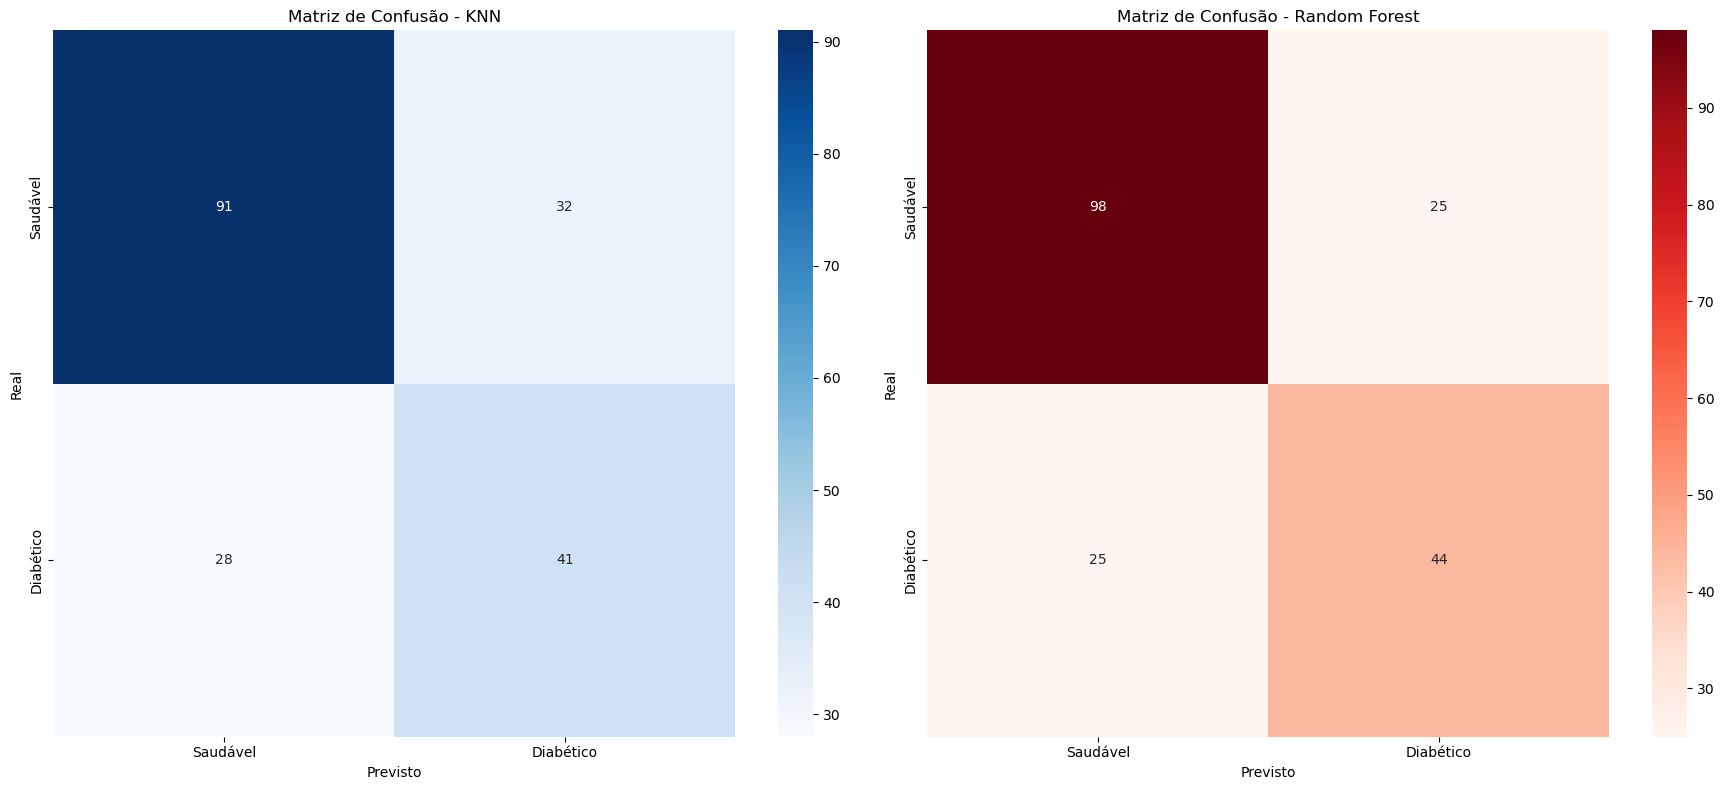

In [155]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Saudável", "Diabético"],
            yticklabels=["Saudável", "Diabético"], ax=ax[0])
ax[0].set_title("Matriz de Confusão - KNN")
ax[0].set_xlabel("Previsto")
ax[0].set_ylabel("Real")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Saudável", "Diabético"],
            yticklabels=["Saudável", "Diabético"], ax=ax[1])
ax[1].set_title("Matriz de Confusão - Random Forest")
ax[1].set_xlabel("Previsto")
ax[1].set_ylabel("Real")
plt.tight_layout()
plt.show()

### 6. Importância das Variáveis (Feature Importance)
Neste bloco final, extraí do Random Forest quais exames mais pesam no diagnóstico. Isso ajuda a dar "explicabilidade" ao modelo.

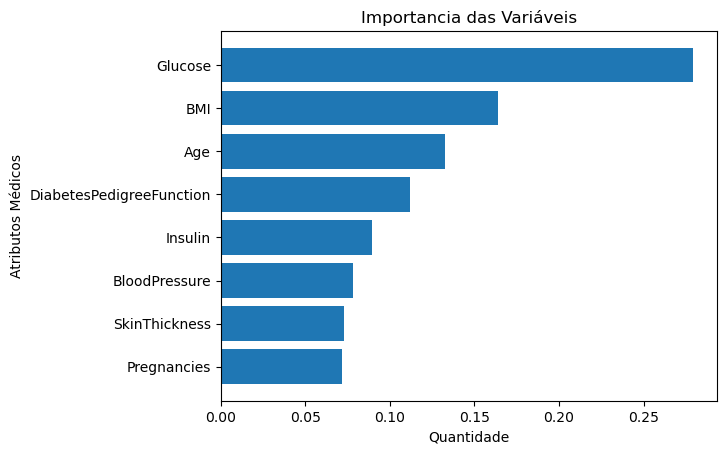

In [156]:
ordem = np.argsort(rf.feature_importances_)
plt.barh(X.columns[ordem], rf.feature_importances_[ordem]) 
plt.title("Importancia das Variáveis")
plt.xlabel("Quantidade")
plt.ylabel("Atributos Médicos")
plt.show()

## Visualização das Fronteiras de Decisão (Glicose vs IMC)

Para entender visualmente como os dados estão distribuídos e onde os modelos podem encontrar dificuldades, plotamos um gráfico de dispersão (*Scatter Plot*).

* **Eixos (Z-Score):** Como os dados passaram pelo `StandardScaler`, os valores `0` representam a média, enquanto `1`, `2`, `-1` e `-2` representam os desvios padrão.
* **Variáveis:** Escolhemos a **Glicose** (coluna index 1) e o **IMC** (coluna index 5), pois são os dois principais indicadores de risco identificados pelo modelo.
* **Cores:** O mapa de cores `coolwarm` diferencia os pacientes **Saudáveis (Azul)** dos **Diabéticos (Vermelho)**.

Este gráfico ajuda a visualizar a "sobreposição" de classes no centro, o que justifica por que a acurácia não é de 100% e por que o Random Forest (que cria regras complexas) se sai melhor que o KNN (que olha apenas a vizinhança).

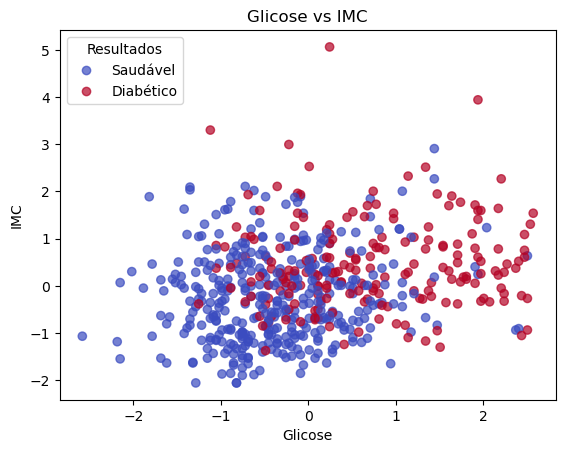

In [157]:
scatter = plt.scatter(X_train[:, 1], X_train[:, 5], c=y_train, cmap="coolwarm", alpha=0.7)
plt.legend(handles = scatter.legend_elements()[0], labels=["Saudável", "Diabético"], title="Resultados")
plt.title('Glicose vs IMC')
plt.xlabel('Glicose')
plt.ylabel('IMC')
plt.show()